In [1]:
# if (!require("BiocManager", quietly = TRUE))
#     install.packages("BiocManager")

# BiocManager::install("apeglm")

In [2]:
library("DESeq2")

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb

Loa

In [3]:
cts <- as.matrix(read.table("counts.csv", header=TRUE, row.names=1, sep = ","))
coldata <- read.table("coldata.txt", header=TRUE, row.names=1)

head(cts)
head(coldata)

,WT10R1,WT10R2,WT10R3,WT10R4,WT15R1,WT15R2,WT15R3,WT15R4,WT20R1,WT20R2,⋯,WT30R3,WT30R4,WT35R1,WT35R2,WT35R3,WT35R4,WTMATR1,WTMATR2,WTMATR3,WTMATR4
Csa00382s010,203,270,153,130,275,244,174,142,101,56,⋯,34,37,1,6,24,0,0,0,0,0
Csa00382s020,1280,1552,1079,863,962,694,468,858,548,396,⋯,674,732,2864,2024,2811,442,2869,2333,3026,2472
Csa00382s030,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Csa00382s040,10,19,17,12,0,5,0,0,0,5,⋯,0,0,0,0,0,0,0,0,0,0
Csa00382s050,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
Csa00382s060,0,7,0,2,0,0,0,1,0,0,⋯,12,0,0,0,0,0,0,0,0,12


,condition,batch
,<chr>,<int>
WT10R1,WT10,1
WT10R2,WT10,1
WT10R3,WT10,1
WT10R4,WT10,1
WT15R1,WT15,1
WT15R2,WT15,1


In [4]:
dds_condition_only <- DESeqDataSetFromMatrix(countData = cts,
                              colData = coldata,
                              design= ~ condition)
dds_condition_only <- DESeq(dds_condition_only)
resultsNames(dds_condition_only) # lists the coefficients

# dds <- DESeqDataSetFromMatrix(countData = cts,
#                               colData = coldata,
#                               design= ~ condition + batch)
# dds <- DESeq(dds)
# resultsNames(dds) # lists the coefficients


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"               "condition_WT15_vs_WT10" 
[3] "condition_WT20_vs_WT10"  "condition_WT25_vs_WT10" 
[5] "condition_WT30_vs_WT10"  "condition_WT35_vs_WT10" 
[7] "condition_WTMAT_vs_WT10"

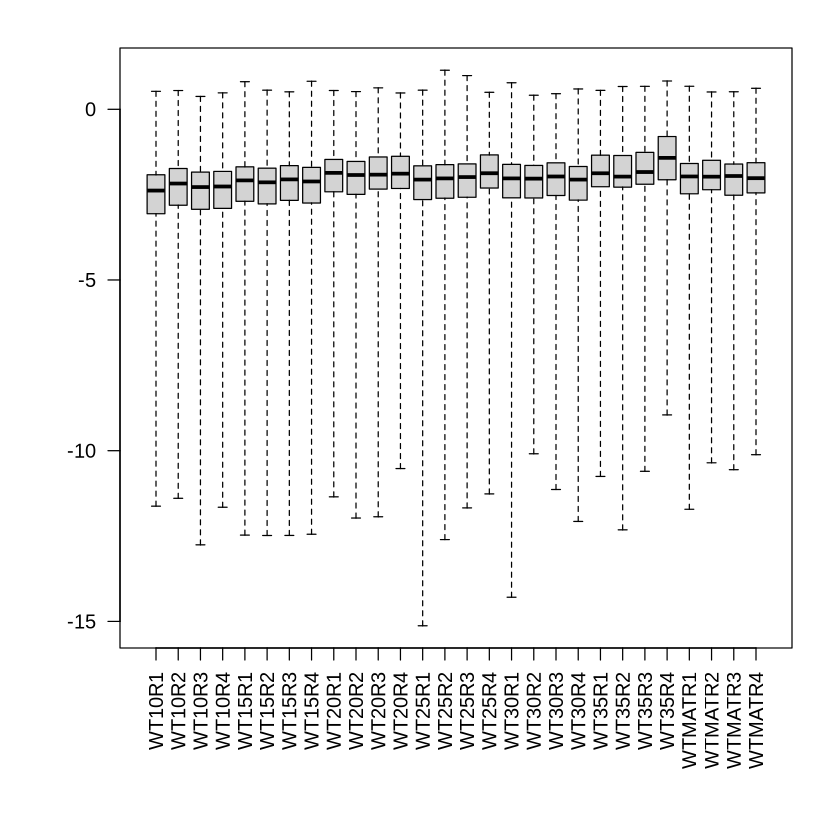

In [5]:
par(mar=c(8,5,2,2))
boxplot(log10(assays(dds_condition_only)[["cooks"]]), range=0, las=2)

using ntop=500 top features by variance



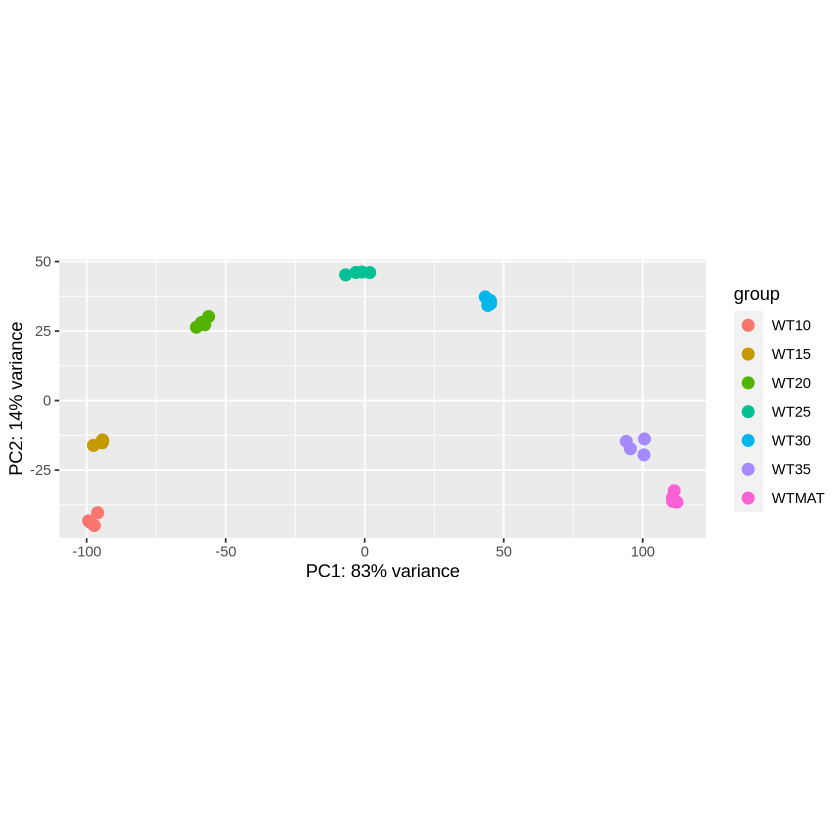

In [6]:
vsd_condition_only <- varianceStabilizingTransformation(dds_condition_only)
plotPCA(vsd_condition_only, intgroup=c("condition"))

# vsd <- varianceStabilizingTransformation(dds)
# plotPCA(vsd, intgroup=c("condition", "batch"))

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition WT35 vs WT10 
Wald test p-value: condition WT35 vs WT10 
DataFrame with 89407 rows and 5 columns
                         baseMean log2FoldChange     lfcSE      pvalue
                        <numeric>      <numeric> <numeric>   <numeric>
Csa00382s010             76.39909      -4.206846   0.51836 9.02465e-17
Csa00382s020           1064.18874       1.028394   0.27041 8.31803e-05
Csa00382s030              0.00000             NA        NA          NA
Csa00382s040              3.55788      -0.595498   1.29239 2.26009e-02
Csa00382s050              0.00000             NA        NA          NA
...                           ...            ...       ...         ...
__no_feature             49018899       0.291546 0.0891274 1.03376e-03
__ambiguous                695445      -0.322380 0.1201991 6.87669e-03
__too_low_aQual           2290939      -0.190345 0.1294917 1.37701e-01
__not_aligned             3855015       0.033505 0.1363713 8.05938e-01
__alignment_not_u

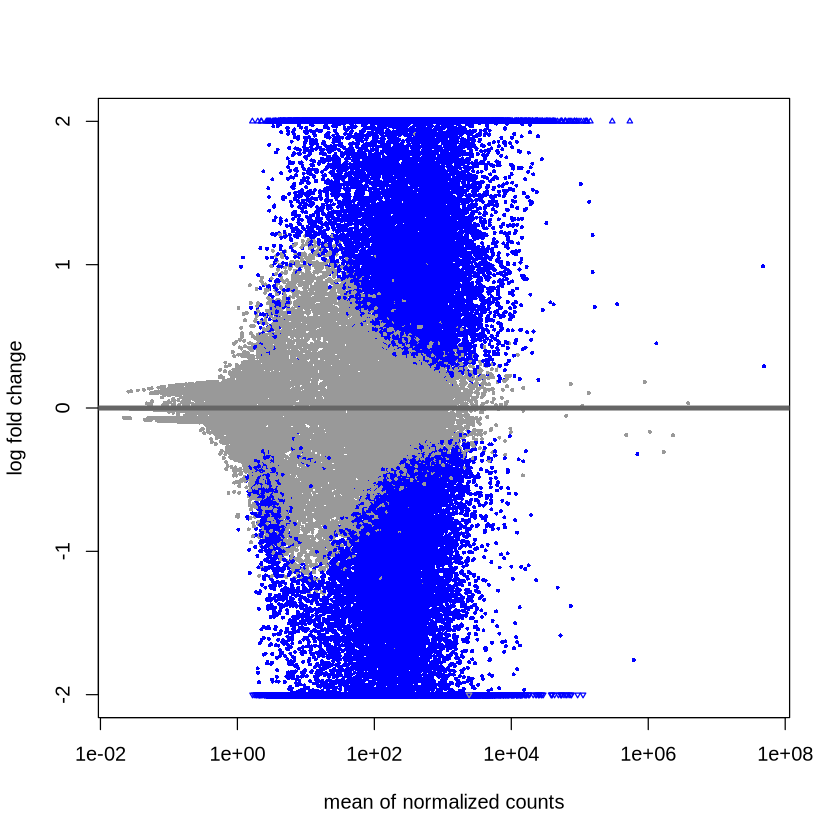

In [13]:
res_condition_only <- results(dds_condition_only, name="condition_WT35_vs_WT10")
# or to shrink log fold changes association with condition:
res_condition_only <- lfcShrink(dds_condition_only, coef="condition_WT35_vs_WT10", type="apeglm")

# write res to file
write.csv(as.data.frame(res_condition_only), file="condition_WT35_vs_WT10_condition_only.csv")

print(res_condition_only)
plotMA(res_condition_only, ylim=c(-2,2))

# With Batch

In [8]:
dds <- DESeqDataSetFromMatrix(countData = cts,
                              colData = coldata,
                              design= ~ condition + batch)
dds <- DESeq(dds)
resultsNames(dds) # lists the coefficients

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  the design formula contains one or more numeric variables with integer values,
  specifying a model with increasing fold change for higher values.
  did you mean for this to be a factor? if so, first convert
  this variable to a factor using the factor() function

estimating size factors



estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing



[1] "Intercept"               "condition_WT15_vs_WT10" 
[3] "condition_WT20_vs_WT10"  "condition_WT25_vs_WT10" 
[5] "condition_WT30_vs_WT10"  "condition_WT35_vs_WT10" 
[7] "condition_WTMAT_vs_WT10" "batch"

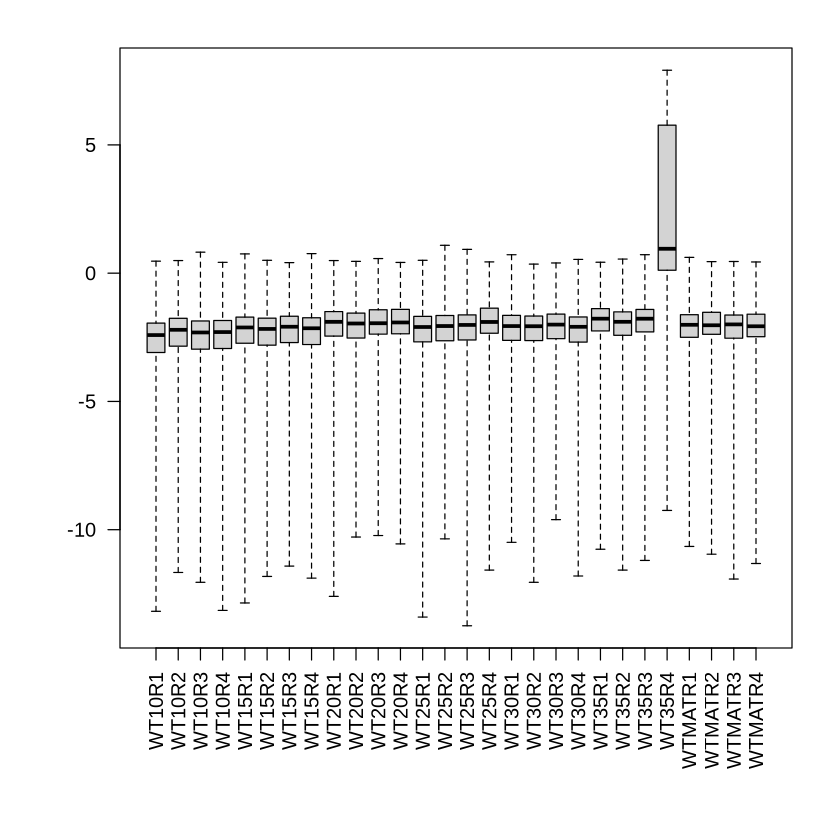

In [9]:
par(mar=c(8,5,2,2))
boxplot(log10(assays(dds)[["cooks"]]), range=0, las=2)

using ntop=500 top features by variance



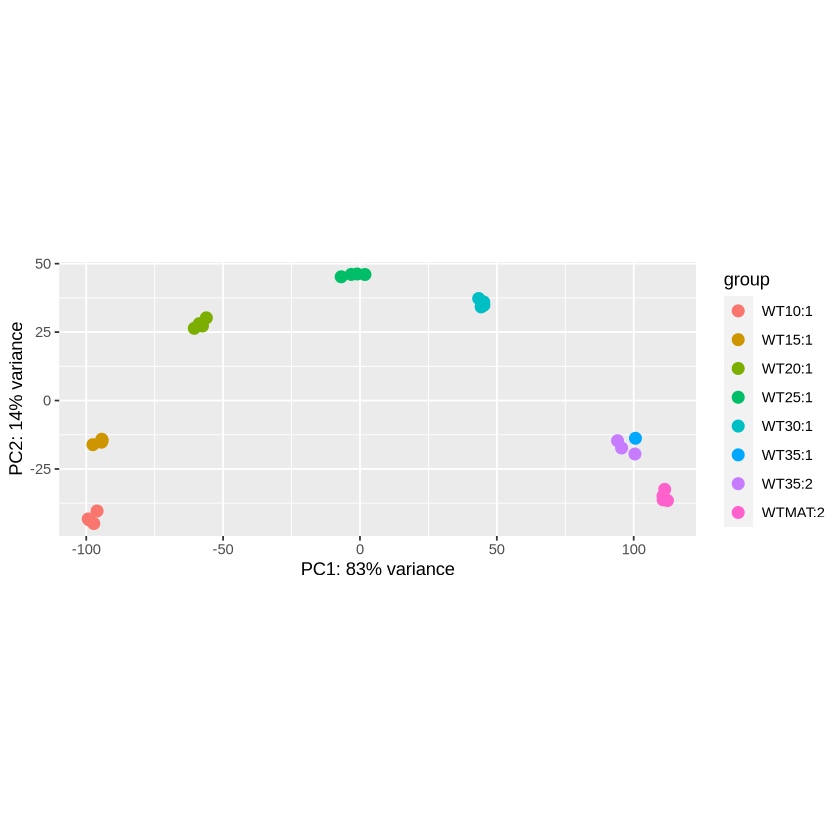

In [10]:
vsd <- varianceStabilizingTransformation(dds)
plotPCA(vsd, intgroup=c("condition", "batch"))

using 'apeglm' for LFC shrinkage. If used in published research, please cite:
    Zhu, A., Ibrahim, J.G., Love, M.I. (2018) Heavy-tailed prior distributions for
    sequence count data: removing the noise and preserving large differences.
    Bioinformatics. https://doi.org/10.1093/bioinformatics/bty895



log2 fold change (MAP): condition WT35 vs WT10 
Wald test p-value: condition WT35 vs WT10 
DataFrame with 89407 rows and 5 columns
                         baseMean log2FoldChange     lfcSE      pvalue
                        <numeric>      <numeric> <numeric>   <numeric>
Csa00382s010             76.39909      -7.902479  2.508499 1.73514e-05
Csa00382s020           1064.18874      -0.573277  0.268036 2.61132e-02
Csa00382s030              0.00000             NA        NA          NA
Csa00382s040              3.55788      -0.171182  1.037664 1.96821e-01
Csa00382s050              0.00000             NA        NA          NA
...                           ...            ...       ...         ...
__no_feature             49018899      0.4807286  0.119590 5.16070e-05
__ambiguous                695445     -0.0986046  0.164254 5.45956e-01
__too_low_aQual           2290939      0.0202748  0.178948 9.04204e-01
__not_aligned             3855015      0.3475928  0.178595 4.78445e-02
__alignment_not_u

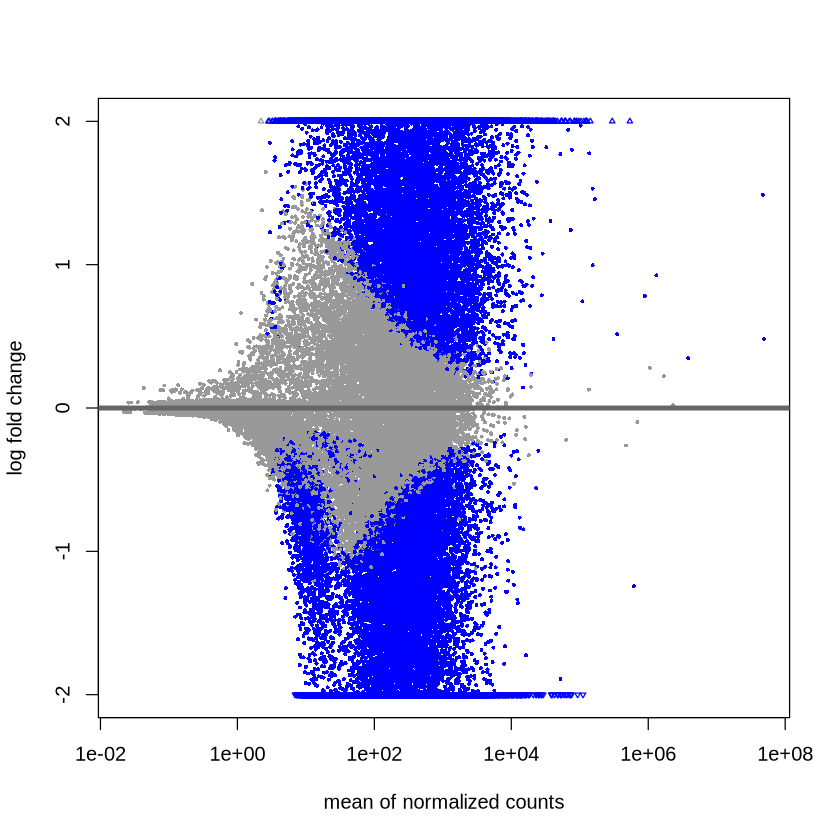

In [12]:
res <- results(dds, name="condition_WT35_vs_WT10")
# or to shrink log fold changes association with condition:
res <- lfcShrink(dds, coef="condition_WT35_vs_WT10", type="apeglm")

# write res to file
write.csv(as.data.frame(res), file="condition_WT35_vs_WT10.csv")

print(res)
plotMA(res, ylim=c(-2,2))